In [ ]:
# pip install linearmodels

In [1]:
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 2. SETTINGS
# ==========================================
folder_path = "SEC_DATA"

important_tags = [
    "NetIncomeLoss",
    "Assets",
    "Liabilities",
    "Revenues",
    "OperatingIncomeLoss"
]

processed_data = []

In [3]:
# 3. PROCESS EACH FILE
# ==========================================
for folder in os.listdir(folder_path):
    print(f"Processing {folder}...")

    num_path = os.path.join(folder_path, folder, "num.txt")
    sub_path = os.path.join(folder_path, folder, "sub.txt")

    # ---- Load num.txt in chunks ----
    chunks = pd.read_csv(num_path, sep='\t', chunksize=500000)

    filtered_chunks = []

    for chunk in chunks:
        chunk = chunk[chunk['tag'].isin(important_tags)]
        chunk = chunk[['adsh', 'tag', 'value']]
        chunk['value'] = pd.to_numeric(chunk['value'], errors='coerce')
        chunk = chunk.dropna()
        filtered_chunks.append(chunk)

    num_df = pd.concat(filtered_chunks, ignore_index=True)

    # Pivot
    pivot_df = num_df.pivot_table(
        index='adsh',
        columns='tag',
        values='value',
        aggfunc='first'
    ).reset_index()

    # Load sub.txt
    sub_df = pd.read_csv(sub_path, sep='\t', usecols=['adsh', 'cik', 'period'])

    # Merge
    merged_df = pd.merge(pivot_df, sub_df, on='adsh', how='left')

    processed_data.append(merged_df)

Processing 2016q1...
Processing 2016q2...
Processing 2016q3...
Processing 2016q4...
Processing 2017q1...
Processing 2017q2...
Processing 2017q3...
Processing 2017q4...
Processing 2018q1...
Processing 2018q2...
Processing 2018q3...
Processing 2018q4...
Processing 2019q1...
Processing 2019q2...
Processing 2019q3...
Processing 2019q4...
Processing 2020q1...
Processing 2020q2...
Processing 2020q3...
Processing 2020q4...
Processing 2021q1...
Processing 2021q2...
Processing 2021q3...
Processing 2021q4...
Processing 2022q1...
Processing 2022q2...
Processing 2022q3...
Processing 2022q4...
Processing 2023q1...
Processing 2023q2...
Processing 2023q3...
Processing 2023q4...
Processing 2024q1...
Processing 2024q2...
Processing 2024q3...
Processing 2024q4...
Processing 2025q1...
Processing 2025q2...
Processing 2025q3...
Processing 2025q4...


C:\Users\AKSHAY\AppData\Local\Temp\ipykernel_4800\1790309426.py:14: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


In [4]:
# 4. COMBINE ALL DATA
# ==========================================
final_df = pd.concat(processed_data, ignore_index=True)
print("Final dataset shape:", final_df.shape)

Final dataset shape: (271315, 8)


In [5]:
# 5. FEATURE ENGINEERING
# ==========================================
df = final_df.copy()

df['ROA'] = df['NetIncomeLoss'] / df['Assets']
df['DebtRatio'] = df['Liabilities'] / df['Assets']
df['CostStructure'] = df['OperatingIncomeLoss'] / df['Revenues']
df['Size'] = np.log(df['Assets'])
df['LogRevenue'] = np.log(df['Revenues'])
df['AssetTurnover'] = df['Revenues'] / df['Assets']
df['ProfitMargin'] = df['NetIncomeLoss'] / df['Revenues']

# Sort and growth
df = df.sort_values(by=['cik', 'period'])
df['Growth'] = df.groupby('cik')['Revenues'].pct_change()

C:\Users\AKSHAY\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\AKSHAY\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\AKSHAY\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\AKSHAY\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\AKSHAY\AppData\Local\Temp\ipykernel_4800\1681079026.py:15: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any n

In [6]:
# 6. CLEAN DATA
# ==========================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

df = df[
    (df['ROA'].between(-1, 1)) &
    (df['DebtRatio'].between(0, 1.5)) &
    (df['CostStructure'].between(-1, 1))
]

print("Clean dataset shape:", df.shape)

Clean dataset shape: (21087, 16)


             Assets   Liabilities  NetIncomeLoss  OperatingIncomeLoss  \
count  2.108700e+04  2.108700e+04   2.108700e+04         2.108700e+04   
mean   7.888949e+09  4.217180e+09   2.119696e+08         1.438325e+08   
std    2.432144e+11  1.659456e+11   1.204196e+10         4.005060e+09   
min    4.625000e+03  0.000000e+00  -1.187300e+10        -1.984300e+10   
25%    3.884594e+07  1.257871e+07  -2.504062e+06        -1.451198e+06   
50%    3.462020e+08  1.247730e+08   1.301890e+05         6.260000e+05   
75%    2.124465e+09  1.009972e+09   1.623594e+07         2.379400e+07   
max    2.250761e+13  2.033876e+13   1.685323e+12         3.757830e+11   

           Revenues           cik        period           ROA     DebtRatio  \
count  2.108700e+04  2.108700e+04  2.108700e+04  21087.000000  21087.000000   
mean   1.326776e+09  1.208004e+06  2.020275e+07     -0.016572      0.538474   
std    3.983583e+10  4.860656e+05  2.870215e+04      0.138132      0.327356   
min    4.890000e+02  2.098

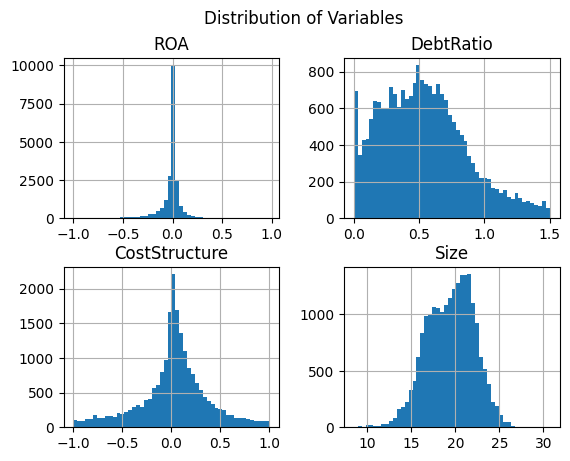

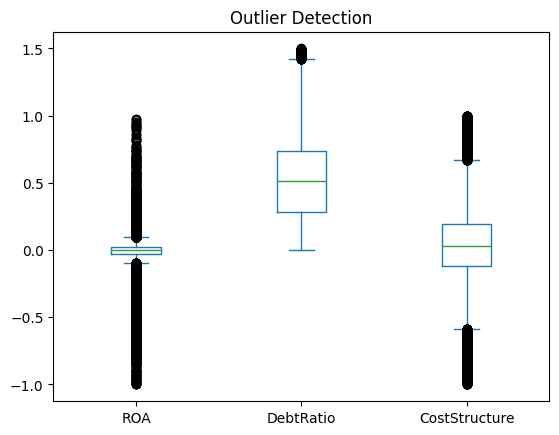

                    ROA  DebtRatio  CostStructure      Size    Growth
ROA            1.000000  -0.115542       0.338002  0.226868  0.002587
DebtRatio     -0.115542   1.000000      -0.055731  0.017760 -0.005345
CostStructure  0.338002  -0.055731       1.000000  0.315027  0.001380
Size           0.226868   0.017760       0.315027  1.000000  0.000755
Growth         0.002587  -0.005345       0.001380  0.000755  1.000000


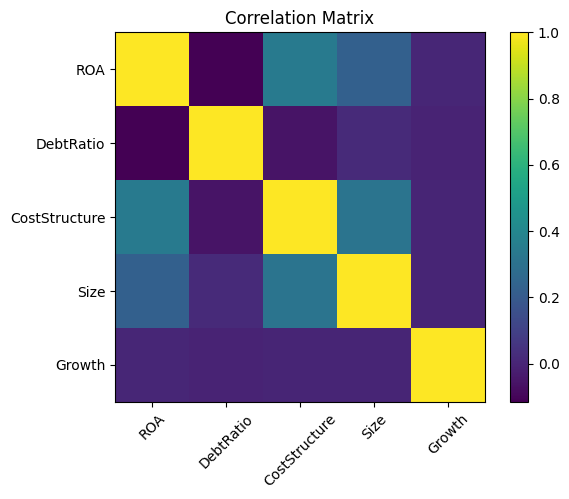

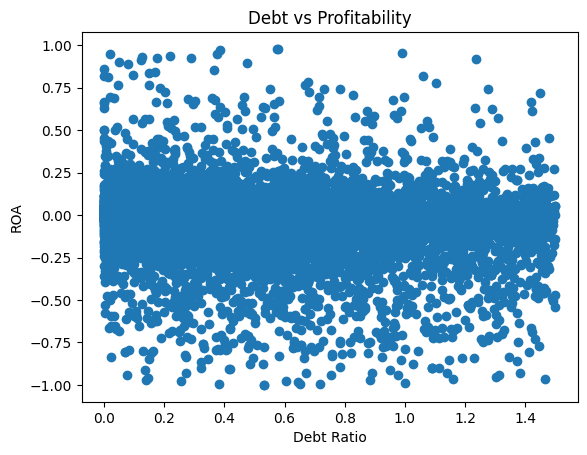

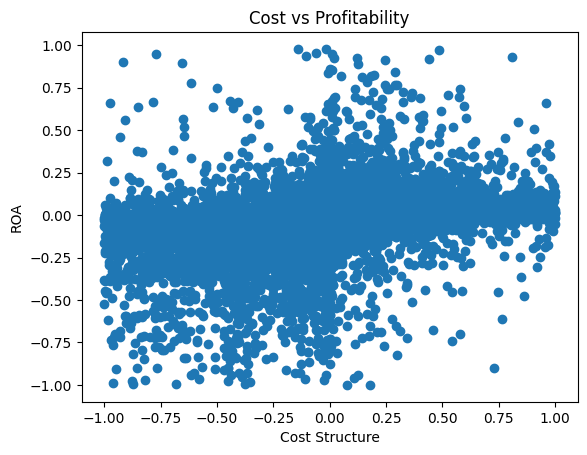

In [7]:
# 7. EDA
# ==========================================

# Summary
print(df.describe())

# Histograms
df[['ROA','DebtRatio','CostStructure','Size']].hist(bins=50)
plt.suptitle("Distribution of Variables")
plt.show()

# Boxplot
df[['ROA','DebtRatio','CostStructure']].plot(kind='box')
plt.title("Outlier Detection")
plt.show()

# Correlation
corr = df[['ROA','DebtRatio','CostStructure','Size','Growth']].corr()
print(corr)

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

# Scatter plots
plt.scatter(df['DebtRatio'], df['ROA'])
plt.xlabel("Debt Ratio")
plt.ylabel("ROA")
plt.title("Debt vs Profitability")
plt.show()

plt.scatter(df['CostStructure'], df['ROA'])
plt.xlabel("Cost Structure")
plt.ylabel("ROA")
plt.title("Cost vs Profitability")
plt.show()

In [8]:
# 8. PREPARE DATA
# ==========================================
X = df[['CostStructure', 'DebtRatio', 'Size', 'LogRevenue', 'AssetTurnover']]
y = df['ROA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# 9. BASELINE MODEL
# ==========================================
rf_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("\nBaseline Model")
print("RMSE:", rmse_base)
print("R²:", r2_base)


Baseline Model
RMSE: 0.11322248715943752
R²: 0.3190267240661391


In [10]:
# 10. HYPERPARAMETER TUNING (GRID SEARCH)
# ==========================================

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# Base model
rf = RandomForestRegressor(random_state=42)

# GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("\nBest Parameters Found:")
print(grid_search.best_params_)

Starting Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters Found:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [11]:
# 11. EVALUATE OPTIMISED MODEL
# ==========================================
y_pred_opt = best_rf.predict(X_test)

rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt = r2_score(y_test, y_pred_opt)

print("\nOptimised Model Performance")
print("RMSE:", rmse_opt)
print("R²:", r2_opt)


Optimised Model Performance
RMSE: 0.11361203557753206
R²: 0.3143328083804149


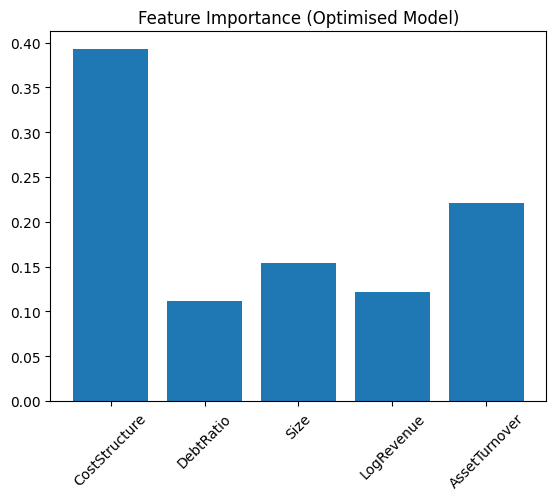

In [12]:
# 12. FEATURE IMPORTANCE (OPTIMISED)
# ==========================================
importance = best_rf.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance (Optimised Model)")
plt.xticks(rotation=45)
plt.show()

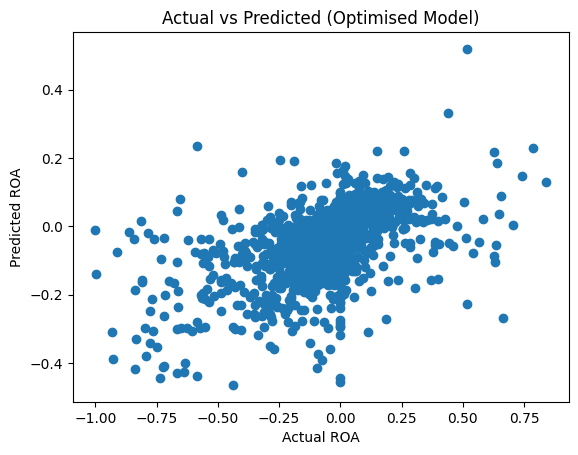

In [13]:
# 13. ACTUAL VS PREDICTED
# ==========================================
plt.scatter(y_test, y_pred_opt)
plt.xlabel("Actual ROA")
plt.ylabel("Predicted ROA")
plt.title("Actual vs Predicted (Optimised Model)")
plt.show()

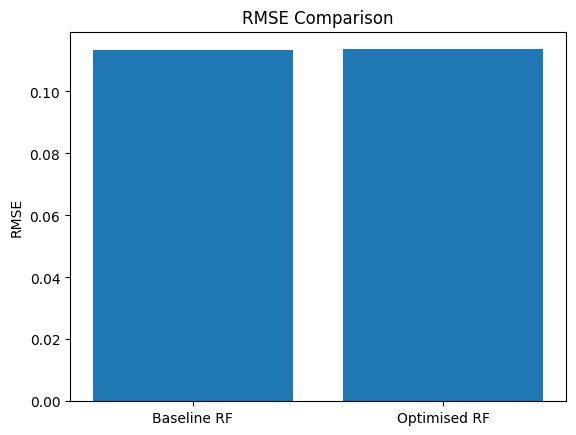

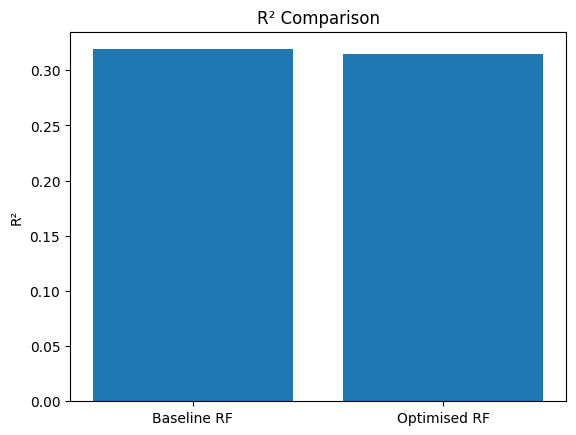

In [14]:
# 14. MODEL COMPARISON (BASELINE vs OPTIMISED)
# ==========================================

# IMPORTANT: Make sure you already have:
# rmse_base, r2_base from your baseline model

models = ['Baseline RF', 'Optimised RF']
rmse_values = [rmse_base, rmse_opt]
r2_values = [r2_base, r2_opt]

# RMSE comparison
plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

# R² comparison
plt.bar(models, r2_values)
plt.title("R² Comparison")
plt.ylabel("R²")
plt.show()

In [17]:
# 15. PANEL REGRESSION (ECONOMETRIC MODEL)
# ==========================================
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Prepare panel data (firm + time)
df_panel = df.set_index(['cik', 'period'])

# Dependent variable
y_panel = df_panel['ROA']

# Independent variables (USE CORE VARIABLES ONLY)
X_panel = df_panel[['CostStructure', 'DebtRatio', 'Size', 'Growth']]

# Add constant
X_panel = sm.add_constant(X_panel)

# Panel Regression Model (Fixed Effects)
panel_model = PanelOLS(y_panel, X_panel, entity_effects=True)

panel_results = panel_model.fit()

print("\nPanel Regression Results")
print(panel_results)


Panel Regression Results
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.0152
Estimator:                   PanelOLS   R-squared (Between):              0.0549
No. Observations:               21087   R-squared (Within):               0.0152
Date:                Mon, Apr 13 2026   R-squared (Overall):              0.0569
Time:                        18:54:28   Log-likelihood                 1.832e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      70.168
Entities:                        2843   P-value                           0.0000
Avg Obs:                       7.4172   Distribution:                 F(4,18240)
Min Obs:                       1.0000                                           
Max Obs:                       44.000   F-statistic (robust):             70.168
  

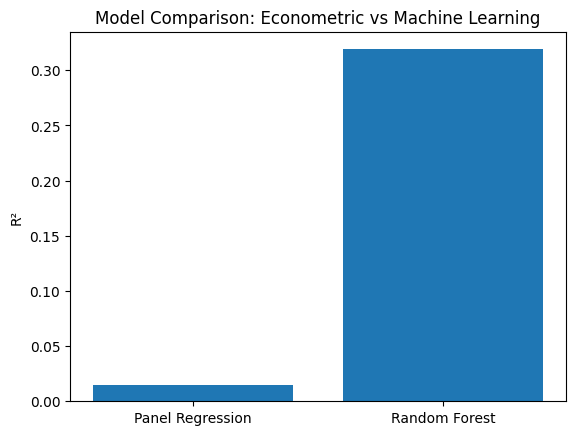

In [18]:
# 16. COMPARE ECONOMETRIC VS ML
# ==========================================

# Extract regression R²
panel_r2 = panel_results.rsquared

# Compare with Random Forest (baseline)
models = ['Panel Regression', 'Random Forest']
r2_values = [panel_r2, r2_base]

plt.bar(models, r2_values)
plt.title("Model Comparison: Econometric vs Machine Learning")
plt.ylabel("R²")
plt.show()